# Subsample a set of input genomes to minimize overrepresentation in gene-by-gene schema

## Introduction

### Aim
Subsample a set of Giardia genomes to reduce overrepresentation of highly similar assemblies in a gene-by-gene schema


### Analysis steps

1. Project a distance matrix obtained using **mash** (kmer size = 51) to a vector space (**t-SNE**)
2. Use a clustering method (**HDBScan**) to determine the similarity among them. 
3. After selecting (through visualization) the ideal parameters for clustering in the given dataset, conduct a grouped subsample.

The **data input** is a square matrix of pre-calculated mash distances (**sourmash v4.8.9**) from n genome assemblies determined to be of good enough quality based on assembly metrics.

### Computing dependencies

The python environment required for this notebook can be reproduced using the `environment.yml` on this directory.

In [ ]:
    # Import all dependencies 

import os
import sys
import argparse
import hdbscan
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as colormaps
from sklearn.manifold import TSNE
from sklearn.cluster import HDBSCAN
from imblearn.under_sampling import RandomUnderSampler


## Analysis steps

Load ans sanitize the data, define a seed for reproducibility, and calculate the sample size (number of inputs) in the dataset

In [ ]:
sour_data = pd.read_csv('../../output/sourmash/sourmash_dist_quast_filtered.csv', sep=',')

    # sanitize the labels
sour_data.columns = sour_data.columns.str.replace('.*/', '', regex=True)
sour_data.index = sour_data.columns

    # random seed for reproducibility, set sample size value
seed = 112233
sample_size = sour_data.shape[1]

### t-SNE

#### Hyperparameter tuning

This loop will show us different topologies according to the perplexity value (influence of neighbors in clustering). The metric is set to `precomputed` as it comes directly from a MASH square distance matrix. 

I am testing perplexity values below 50, as recommended in the t-SNE method, and evaluating between 2500 and 5000 iterations for convergence. 


In [ ]:
# define range of perplexity and iterations
perplexity = np.arange(10, 51, 10)
iters =  (2500, 5000)
cols = math.ceil(len(perplexity) / 3)

# produce a multiplot of results by perplexity in the same max_iter value
# capture divergence value for each iteration

for value in iters:
    
    divergence = []        
    fig, axs = plt.subplots(3, cols, figsize=(12,15), facecolor='w', layout="constrained")
    fig.suptitle(
        "Topology at different perplexity (p) values with " +
        str(value) + " iterations",  
        fontsize=16, va='bottom', weight='bold'
        ) 
    axs = axs.ravel()

        # pair fit [KL divergence] with perplexity values
    for index, p in enumerate(perplexity):
        
        model = TSNE(
            n_components=2, 
            metric='precomputed', init="random",
            perplexity=p, max_iter=value)
        fitted = model.fit_transform(sour_data)
        divergence.append(model.kl_divergence_)
        
            # plot 2D projections
        axs[index].scatter(fitted[:, 0], fitted[:,1], 
                        color=plt.cm.tab20(index) )
        axs[index].set_xlabel("p = " + str(p),
                            fontsize=14)
        
        # plot perplexity vs KL divergence 
    plt.plot(
        perplexity, divergence, color='red', 
        marker='o', fillstyle='full')

**WARNING:** your choice of hyperparameter may vary when you run it, make sure to visualize your data.  

We find convergence of clustering with at least 2500 iterations using a perplexity value around ~40 when only analyzing the samples passing the QUAST filer. 
- Recommended: run the model with the chosen perplexity value to verify if the same topology is reproduced (**see below**)
- The embeddings from a fitted model (with a random seed for reproducibility) are saved. 
    - Proper labels are attached to this new data frame based on the input data.

In [22]:
%%script false --no-raise-error
## optional snippet

fig, axs = plt.subplots(3,3, figsize=(15,15), 
                facecolor='w', layout="constrained")
fig.suptitle("Examples of iterations with selected hyperparameters",
        fontsize=16, va='bottom', weight='bold') 
axs = axs.ravel()

for index in range(0,9):
        model = TSNE(
                n_components=2, metric="precomputed",
                init="random", perplexity=40,
                max_iter=5000)
        fitted = model.fit_transform(sour_data)
        
        axs[index].scatter(fitted[:, 0], fitted[:, 1],
                           color=plt.cm.tab20(index))


In [23]:
        ## saving embeddings with a seed number
tsne = TSNE(
        n_components=2, random_state=seed, 
        metric='precomputed', init="random",
        perplexity=40, max_iter=2500)
tsne = tsne.fit_transform(sour_data)

vector_mat = pd.DataFrame(tsne, columns=['t-SNE-1', 't-SNE-2'])
vector_mat.index= sour_data.index

### HDBSCAN clustering

#### Define a ploting function

The function takes a numpy array with the clustering labels to produce a scatter plot colored by cluster [_if available_]. 

- The size of a point represents the probability of belonging to its cluster
- Unclustered values are marked with a black "X"

In [24]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    
    # optional: transform pd.dataframe to numpy
    if isinstance(X, pd.DataFrame):
        X = X.values  
    if isinstance(labels, pd.Series):
        labels = labels.values
    
    # creates a new ploting space if axes is not specified
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))
    
    # labels and probabilities are set to "1" if not specified
    labels = labels if labels is not None else np.ones(X.shape[0])
    probs = probabilities if probabilities is not None else np.ones(X.shape[0])
    
    # selects colors in spectra palette according to set number
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    # The probability of a point belonging to its labeled cluster determines
        # the size of its marker
    proba_map = {idx: probs[idx] for idx in range(len(labels))}    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
        class_index = np.where(labels == k)[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6 if k == -1 else 5 + 7 * proba_map[ci],
            )
    
    # Improve labelling
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" \n {parameters_str}"
    ax.set_title(title,  fontsize=14)
    plt.tight_layout()

#### Parameter tuning

**WARNING:** your choice of hyperparameter may vary according to your input, visualize to decide. 

HDBSCAN will find the optimal epsilon automatically, but we should tune the `min_cluster_size` and the `min_samples` values. 

- We see that small `min_cluster_sizes` (~ 3) are not ideal as they create many small clusters with doubtful separation
- If we go above 30, it fails to select one region with obvious high density
- We want to be somehow conservative and only samples with a definitive association so better to go with an intermediate value 0f 12

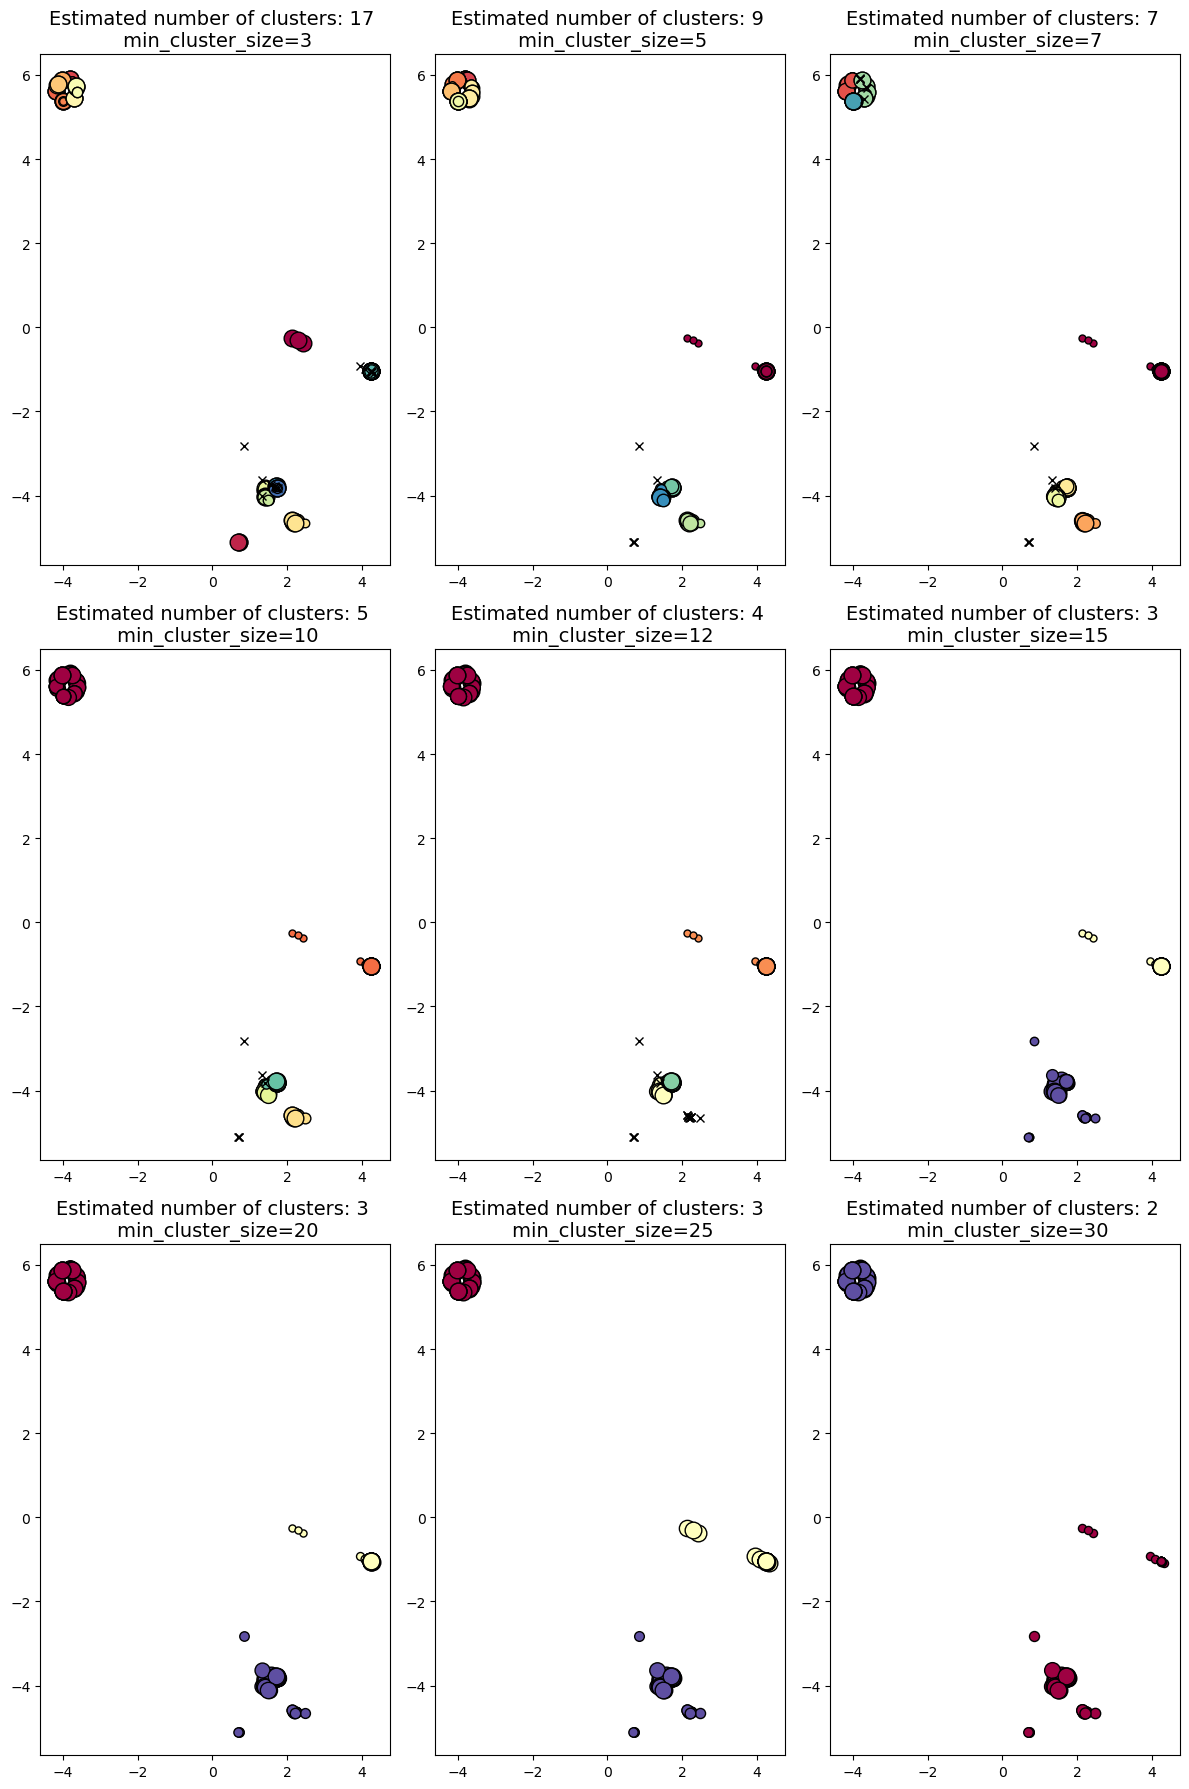

In [26]:
# MANUAL INPUT: define a set of sensible cluster sizes
cluster_sizes = [3, 5, 7, 10, 12, 15, 20, 25, 30]

fig, axes = plt.subplots(3, 3, figsize=(12,18))
axes = axes.ravel()

for i, size in enumerate(cluster_sizes):
    # pass cluster size into function
    hdb = HDBSCAN(
        algorithm="auto", 
        cluster_selection_method="eom", 
        min_cluster_size=size
    ).fit(vector_mat)
    
    # create a dictionary for plotting
    param_dict = {"min_cluster_size": size}
    plot(vector_mat, hdb.labels_, hdb.probabilities_, param_dict, ax=axes[i])

The larger the value of `min_samples` you provide, the more conservative the clustering. We will explore the ideal case for our dataset, using the `min_cluster_size` selected in the previous step.

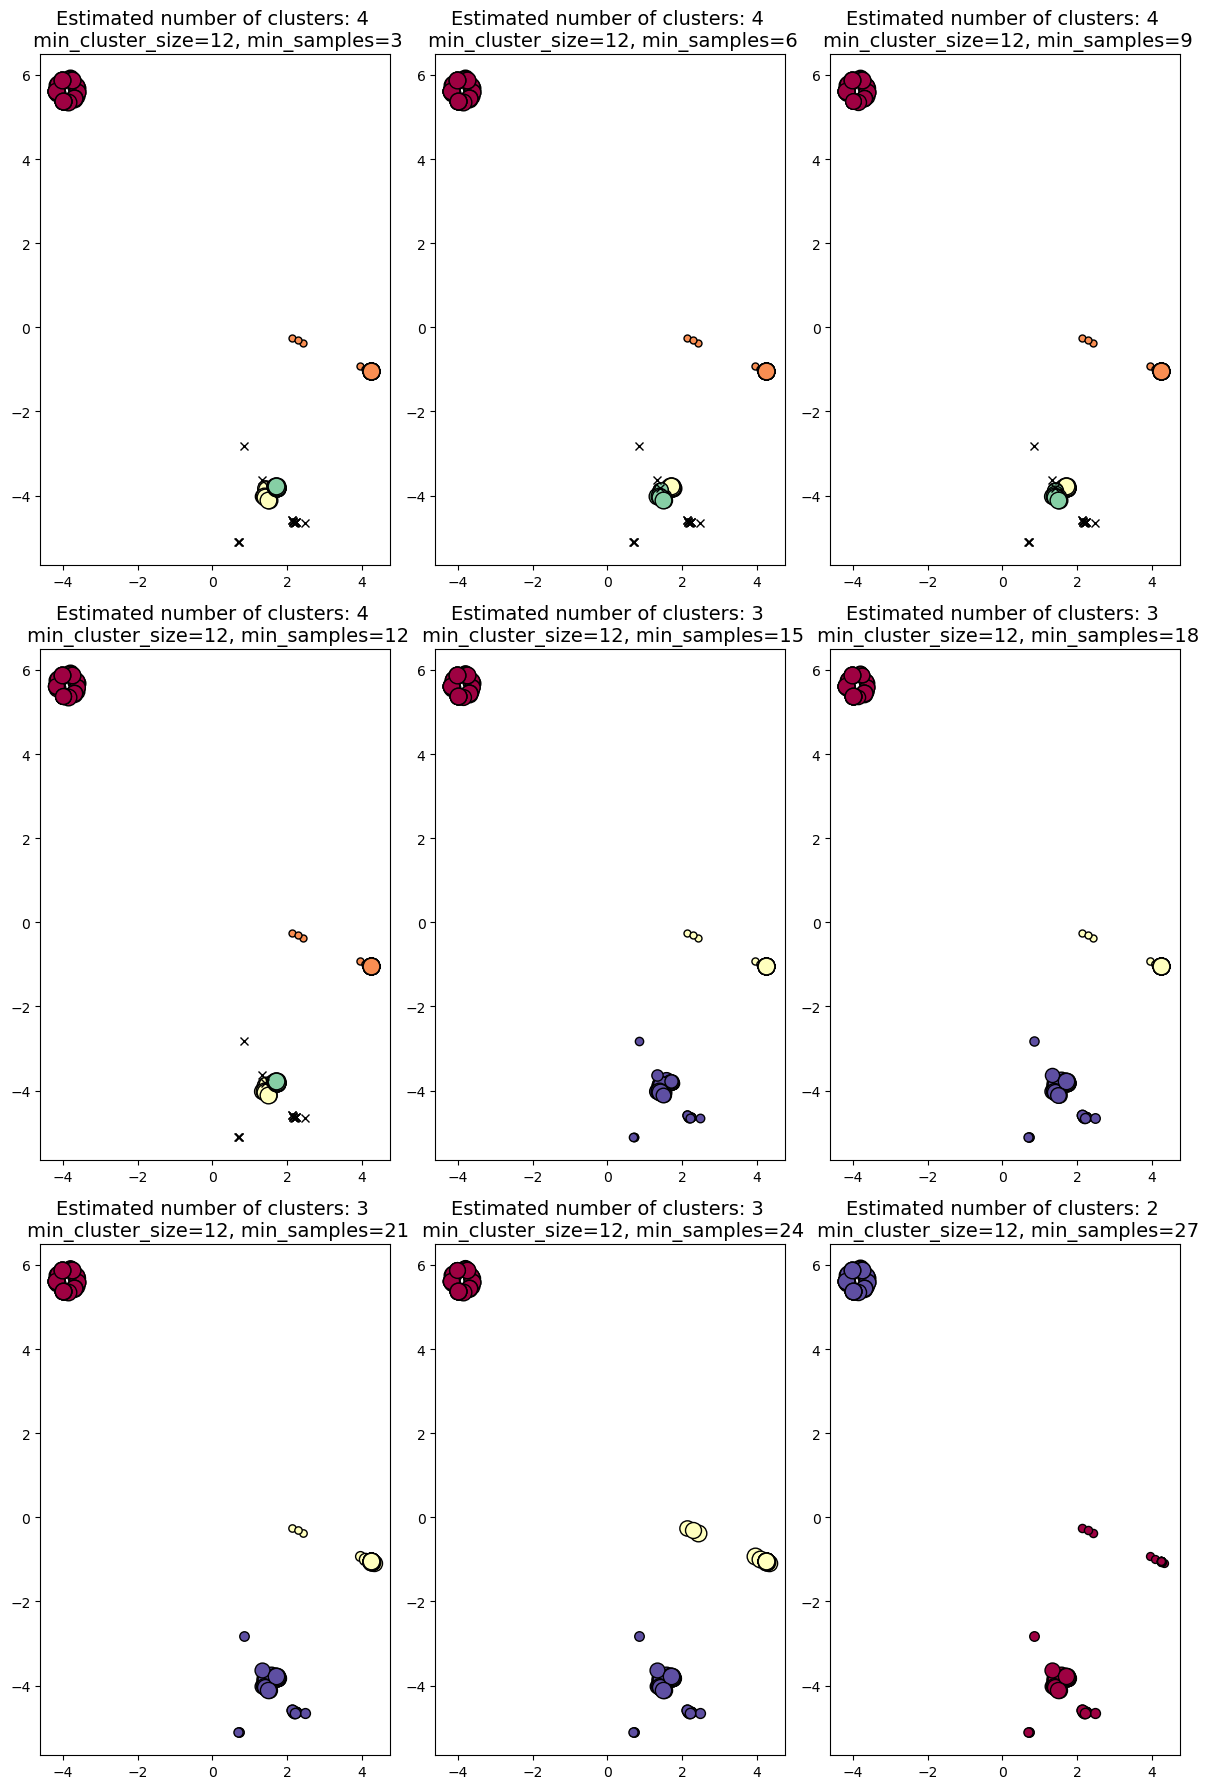

In [ ]:
# MANUAL INPUT - add selected cluster size and check sensible values for min_samples
selected_min_cluster_size = 12
min_samples = np.arange(3, 30, 3)


fig, axes = plt.subplots(3, 3, figsize=(12,18))
axes = axes.ravel()

for i, val in enumerate(min_samples):
    hdb_fit = HDBSCAN(
        algorithm="auto", 
        cluster_selection_method="eom",
        min_cluster_size = selected_min_cluster_size,
        min_samples = val
    ).fit(vector_mat)

    labels = hdb_fit.labels_

    # create a dictionary for plotting
    param_dict = {"min_cluster_size": selected_min_cluster_size,
                  "min_samples": val}
    
    plot(vector_mat, hdb_fit.labels_, hdb_fit.probabilities_, param_dict, ax=axes[i])
    


**WARNING:** your choice of hyperparameters may vary when you run it. 

We'll go with a `min_cluster_size=12` and `min_samples=10`. 

- The aim is to avoid losing a significant portion of the results 
- We use the implementation in the `hdbscan` module instead of in `sklearn-env` to show the tree-form topology

/home/mdprieto/.conda/envs/tsne/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mdprieto/.conda/envs/tsne/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: ylabel='$\\lambda$ value'>

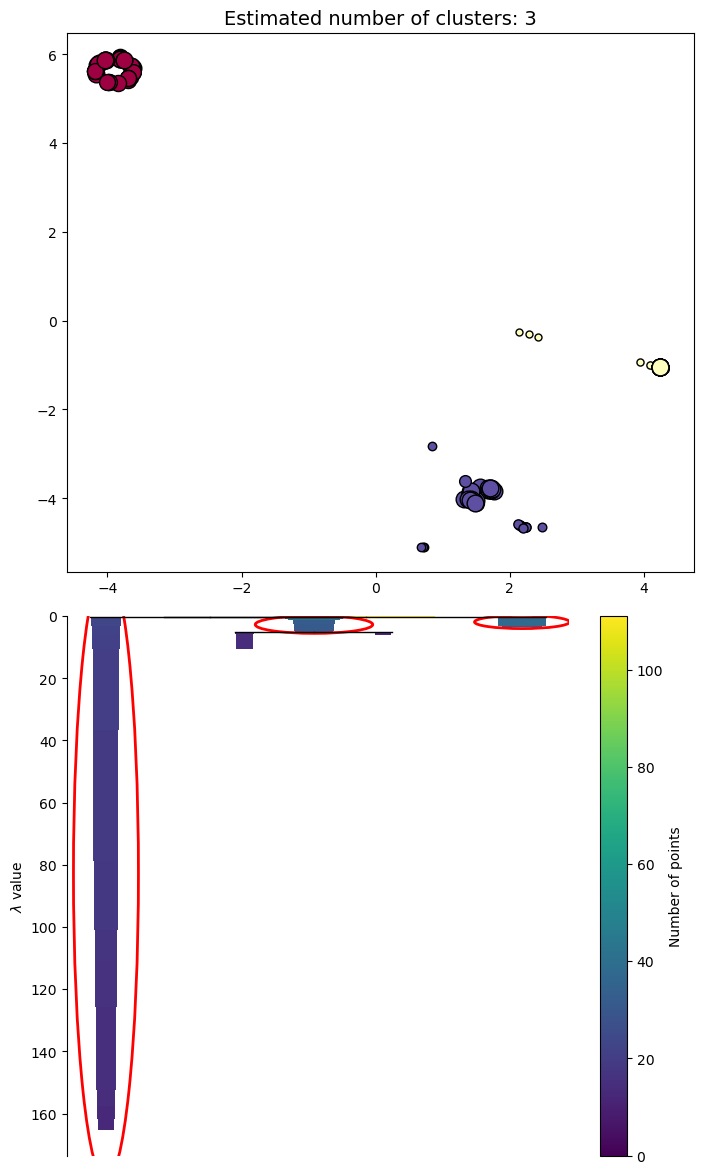

In [37]:
hdb_final = hdbscan.HDBSCAN(algorithm="best", cluster_selection_method="eom",
                            min_cluster_size=12, min_samples=12)

hdb_final_fit = hdb_final.fit(vector_mat)

    # plot the selected clustering and the hierarchical tree
fig, axs = plt.subplots(2, 1, figsize=(7, 12))
plot(vector_mat, 
     hdb_final_fit.labels_, 
     hdb_final_fit.probabilities_, 
     ax=axs[0])

hdb_final_fit.condensed_tree_.plot(select_clusters=True)

### Subsampling informed by clustering

A new dataset with cluster assignment is created for subsampling. To allow visualization of the clustering hierarchy is better to use the library `hdbscan` for the algorithm instead of `sklearn`'s implementation

- Non-clustered samples must be retained so they are extracted from the primary data frame
- To balance the overrepresentation of certain clusters we perform undersampling
    - Here we use the `RandomUnderSampler` method from the module `imbalance-learn`

In [38]:
vector_mat['hdbscan'] = hdb_final_fit.labels_

# sample without replacement, seed for reproducibility
rus=RandomUnderSampler(
    random_state=seed, 
    replacement=False,
    sampling_strategy='auto')

# input whole dataframe and labels
undersampled, labels = rus.fit_resample(vector_mat, vector_mat['hdbscan'])

## Validation and export

Calculate frequency tables showcasing the initial and adjusted distribution of labels.

The data is exported to define the gene-by-gene schema in the `nf_chewbbaca` pipeline

In [ ]:
# final frequencies in sample

print(f"Initial matrix")
print(
    vector_mat['hdbscan']
    .replace(-1, "unclustered")
    .value_counts(normalize=True)
    .reset_index(name="Frequency")
    .rename(columns={'hdbscan':'HDBSCAN cluster'})  )

print(f"\nSampled matrix")
print(
    undersampled['hdbscan']
    .replace(-1, "unclustered")
    .value_counts(normalize=True)
    .reset_index(name="Frequency")
    .rename(columns={'hdbscan':'HDBSCAN cluster'})  )

# save only rownames
undersampled.to_csv(
    '../../processed_data/accessions/clustered_subsample_hbscan.txt', 
    sep='\t', 
    header=False, 
    columns=[])


Initial matrix
   HDBSCAN cluster  Frequency
0                2   0.423423
1                0   0.342342
2                1   0.234234

Sampled matrix
   HDBSCAN cluster  Frequency
0                0   0.333333
1                1   0.333333
2                2   0.333333


OSError: Cannot save file into a non-existent directory: '../../processed_data/accession'